# WZA block-Manhattan — SV climate-GEA on hapFIRE LD blocks

The per-SV two-stage permutation p-values are noisy; **WZA** aggregates them to the
phase-1 **hapFIRE LD blocks** (1.05 M SNPs → 16,674 blocks), exactly as the GrENE-net
project did — Booker weighted-Z (weight = MAF·(1−MAF)) + the SNP-number spline
correction → one `Z_pVal` per block. Run here with **no MAF filter** (all SVs; low-MAF
SVs are auto-downweighted), for both Stage-1 statistics:

- **A — `dp`**: gen-3 endpoint Δp = p₃ − p₀
- **B — `scoef`**: gen0→3 logit-slope selection coefficient

Small `Z_pVal` = block whose SVs are more climate-associated than the genome-wide
background (the spline correction is genomic-control-like, so this tests **outlier
blocks**, not the polygenic background itself).


## Block-Manhattan (A = Δp, B = selection coefficient)

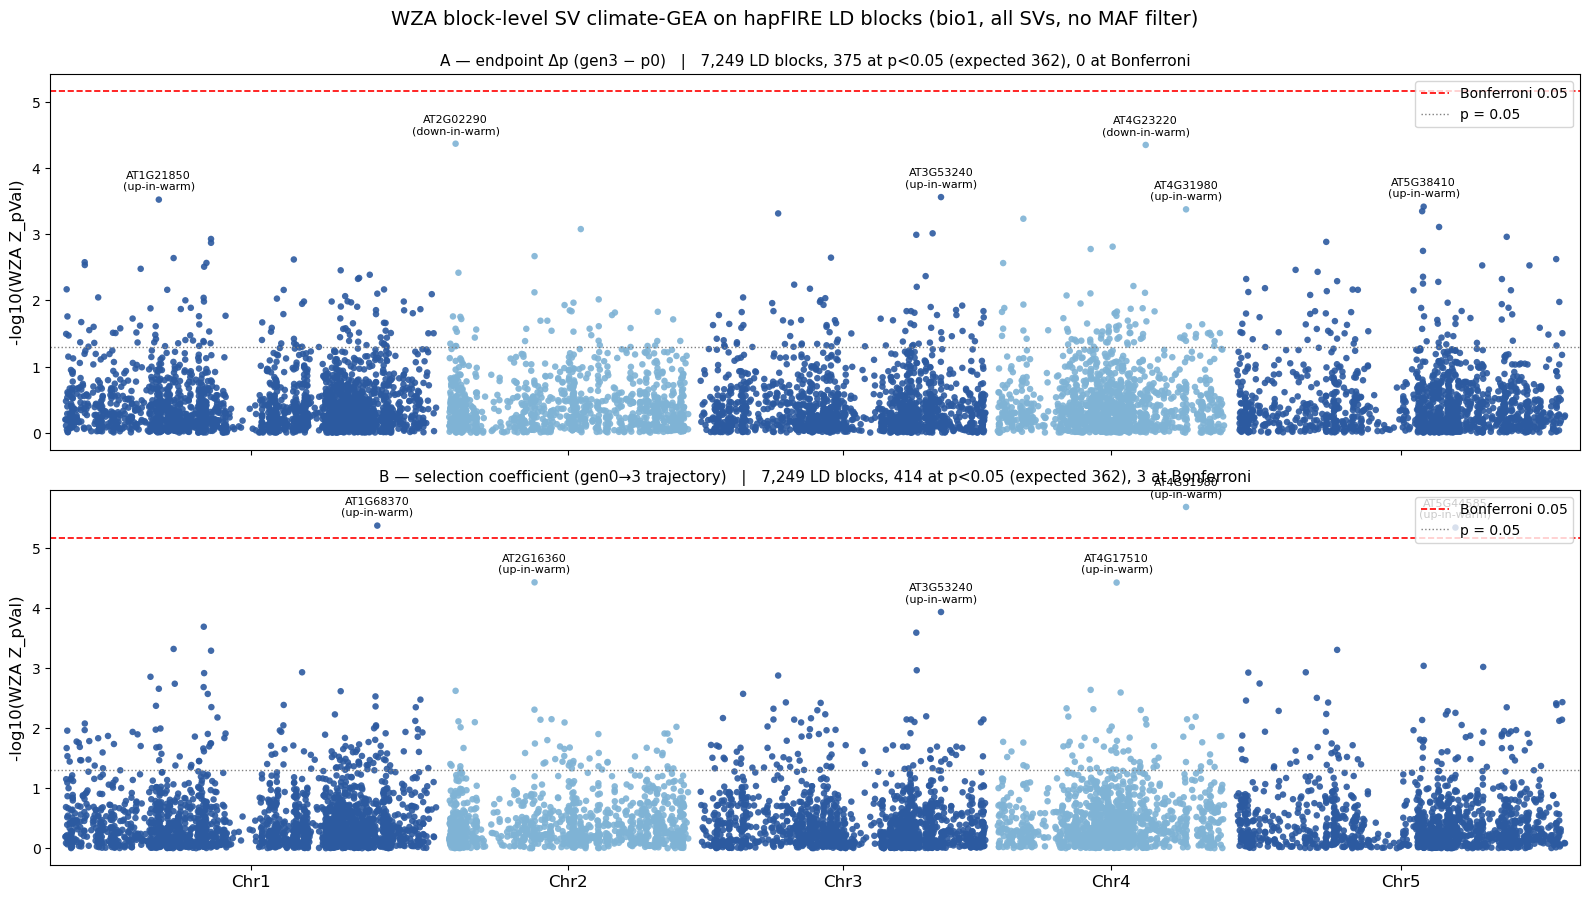

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
WZ = "/global/scratch/users/tbellg/kmate/results/grenenet_gea/gea/wza"
order = [f"Chr{i}" for i in range(1, 6)]
titles = {"dp": "A — endpoint Δp (gen3 − p0)",
          "scoef": "B — selection coefficient (gen0→3 trajectory)"}
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
for ax, s in zip(axes, ("dp", "scoef")):
    w = pd.read_csv(f"{WZ}/wza_{s}_bio1.csv"); w = w[w.Z_pVal.notna()].copy()
    w["chrom"] = "Chr" + w.block.str.split("_").str[0]
    w = w[w.chrom.isin(order)]; w["chrom"] = pd.Categorical(w.chrom, order, ordered=True)
    w = w.sort_values(["chrom", "mid_pos"]); off, cum, ticks = {}, 0, []
    for c in order:
        off[c] = cum; cmax = w.loc[w.chrom == c, "mid_pos"].max()
        ticks.append(cum + cmax / 2); cum += cmax + 1e6
    w["g"] = w.mid_pos + w.chrom.map(off).astype(float)
    w["mlp"] = -np.log10(w.Z_pVal.clip(lower=1e-12))
    nb = len(w); bonf = -np.log10(0.05 / nb)
    for i, c in enumerate(order):
        sd = w[w.chrom == c]
        ax.scatter(sd.g, sd.mlp, s=22, color=["#2c5aa0", "#7fb3d5"][i % 2],
                   edgecolor="none", alpha=.9)
    ax.axhline(bonf, color="r", lw=1.2, ls="--", label="Bonferroni 0.05")
    ax.axhline(-np.log10(0.05), color="gray", lw=1, ls=":", label="p = 0.05")
    t = pd.read_csv(f"{WZ}/wza_{s}_bio1.top.csv").head(6)
    t["chrom"] = "Chr" + t.block.str.split("_").str[0]
    for _, r in t.iterrows():
        gx = r.mid_pos + off.get(r.chrom, 0)
        lab = r.gene_name if isinstance(r.gene_name, str) else r.gene
        ax.annotate(f"{lab}\n({r.dir})", (gx, -np.log10(max(r.Z_pVal, 1e-12))),
                    fontsize=8, ha="center", xytext=(0, 7), textcoords="offset points")
    ax.set_xticks(ticks); ax.set_xticklabels(order, fontsize=12)
    ax.set_ylabel("-log10(WZA Z_pVal)", fontsize=12)
    nsig = (w.Z_pVal < 0.05).sum(); nbonf = (w.Z_pVal < 0.05 / nb).sum()
    ax.set_title(f"{titles[s]}   |   {nb:,} LD blocks, {nsig} at p<0.05 "
                 f"(expected {int(0.05*nb)}), {nbonf} at Bonferroni", fontsize=11)
    ax.legend(fontsize=10, loc="upper right"); ax.margins(x=0.01)
fig.suptitle("WZA block-level SV climate-GEA on hapFIRE LD blocks "
             "(bio1, all SVs, no MAF filter)", fontsize=14, y=0.995)
plt.tight_layout(); plt.show()

## QQ of block-level Z_pVal

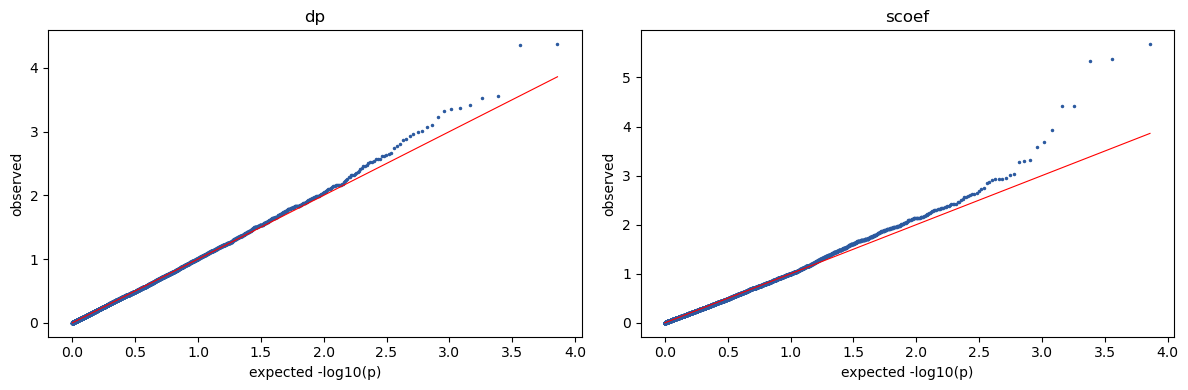

In [2]:
# QQ of block Z_pVal (vs uniform): A hugs the line (polygenic, no outliers);
# B lifts off in the tail (a few real outlier blocks).
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for a, s in zip(ax, ("dp", "scoef")):
    p = pd.read_csv(f"{WZ}/wza_{s}_bio1.csv").Z_pVal.dropna().values
    obs = -np.log10(np.sort(p)); exp = -np.log10(np.linspace(1/len(p), 1, len(p)))
    a.plot(exp, obs, ".", ms=3, color="#2c5aa0"); mx = exp.max()
    a.plot([0, mx], [0, mx], "r-", lw=.8); a.set_title(s)
    a.set_xlabel("expected -log10(p)"); a.set_ylabel("observed")
plt.tight_layout(); plt.show()

## Top blocks (gene-annotated)

In [3]:
# Top blocks per statistic (gene-annotated; dir = mean Δp direction, + = up-in-warm).
for s in ("dp", "scoef"):
    t = pd.read_csv(f"{WZ}/wza_{s}_bio1.top.csv")
    print(f"\n===== {s}: top blocks by Z_pVal =====")
    cols = ["block","chrom","mid_pos","SNPs","Z","Z_pVal","dir","n_up","n_dn","gene_name","flower_locus"]
    print(t[cols].head(12).to_string(index=False))


===== dp: top blocks by Z_pVal =====
 block chrom    mid_pos  SNPs        Z   Z_pVal          dir  n_up  n_dn gene_name  flower_locus
 2_195  Chr2   601536.0    68 4.570025 0.000043 down-in-warm    11    57 AT2G02290           NaN
4_2519  Chr4 12157244.0   127 5.083626 0.000045 down-in-warm    56    71 AT4G23220           NaN
3_3018  Chr3 19740321.0     3 3.492259 0.000274   up-in-warm     3     0 AT3G53240           NaN
 1_923  Chr1  7670864.0     2 3.460320 0.000299   up-in-warm     2     0 AT1G21850           NaN
5_1137  Chr5 15377767.5     2 3.392711 0.000382   up-in-warm     2     0 AT5G38410           NaN
4_2781  Chr4 15468585.5    22 3.523983 0.000419   up-in-warm    14     8 AT4G31980           NaN
5_1060  Chr5 15254188.0     2 3.348661 0.000448   up-in-warm     2     0       NaN           NaN
 3_589  Chr3  6379685.0    91 4.004803 0.000483   up-in-warm    52    39 AT3G18520           NaN
 4_225  Chr4  2119044.0     1 3.266815 0.000582   up-in-warm     1     0 AT4G04330       